In [1]:
from scoresbibm.src.tasks.all_conditional_tasks import TwoMoonsAllConditionalTask, SLCPAllConditionalTask, NonlinearGaussianTreeAllConditionalTask, NonlinearMarcovChainAllConditionalTask
from scoresbibm.src.tasks.sbibm_tasks import TwoMoons, SBIBMTask
from scoresbibm.src.tasks.base_task import InferenceTask, Task, AllConditionalTask

import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

In [17]:
#task = TwoMoonsAllConditionalTask()
#task = SLCPAllConditionalTask()
#task = NonlinearMarcovChainAllConditionalTask()
task = NonlinearGaussianTreeAllConditionalTask()

In [18]:
from probjax.utils.graph import moralize


In [19]:
dim = jax.tree_util.tree_reduce(lambda x, y: x + y, task.var_sizes)

In [20]:
base_mask_fn = task.get_base_mask_fn()
node_id = jnp.arange(dim)

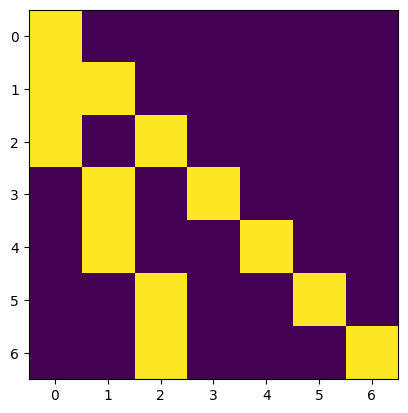

In [21]:
base_mask = base_mask_fn(node_id, None)
plt.imshow(base_mask)

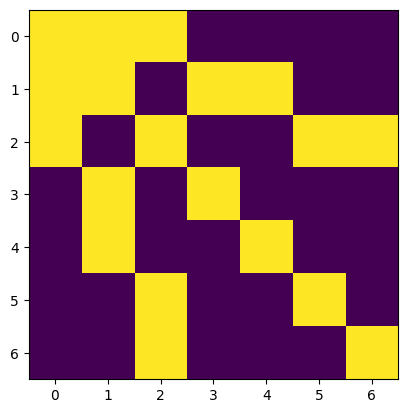

In [22]:
base_mask = base_mask_fn(node_id, None)
plt.imshow(moralize(base_mask))

In [ ]:
from probjax.utils.graph import min_faithfull_mask, faithfull_mask

In [6]:
base_mask = base_mask_fn(node_id, None)
#condition_mask = jnp.array([1]*2 + [0]*6+ [0]*2 + [0]*5 + [1]*5, dtype=bool)
condition_mask = jax.random.bernoulli(jax.random.PRNGKey(2), p=0.1, shape=(dim,)).astype(bool)
with jax.disable_jit():
    mask = min_faithfull_mask(base_mask,condition_mask, conditioned_nodes="removed",top_mode=0)
print(condition_mask)
plt.imshow(mask)

NameError: name 'node_id' is not defined

In [5]:
base_mask = base_mask_fn(node_id, None)
condition_mask = jnp.array([1]*2 + [0]*6+ [0]*2 + [0]*5 + [1]*5, dtype=bool)
#condition_mask = jax.random.bernoulli(jax.random.PRNGKey(2), p=0.1, shape=(dim,)).astype(bool)
mask = faithfull_mask(base_mask,condition_mask)
print(condition_mask)
plt.imshow(mask)

NameError: name 'faithfull_mask' is not defined

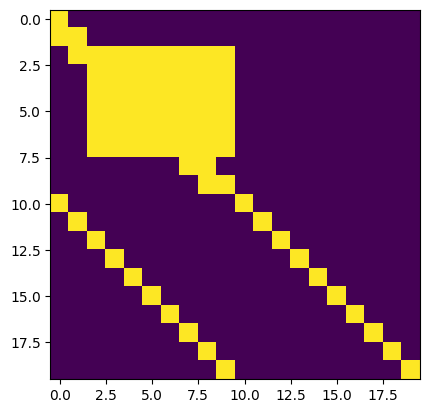

In [14]:
plt.imshow(mask)

In [6]:
reference_sampler = task.get_reference_sampler()

In [7]:
# Two moons
theta, x = task.get_thetas_xs(1, rng=jax.random.PRNGKey(0))
theta_dim = theta.shape[-1]
x_dim = x.shape[-1]
print(x_dim, theta_dim)
samples = reference_sampler.sample(2000,x_o = x[0], condition_mask=jnp.array([0]*theta_dim + [1] * x_dim), rng=jax.random.PRNGKey(0))

2 2


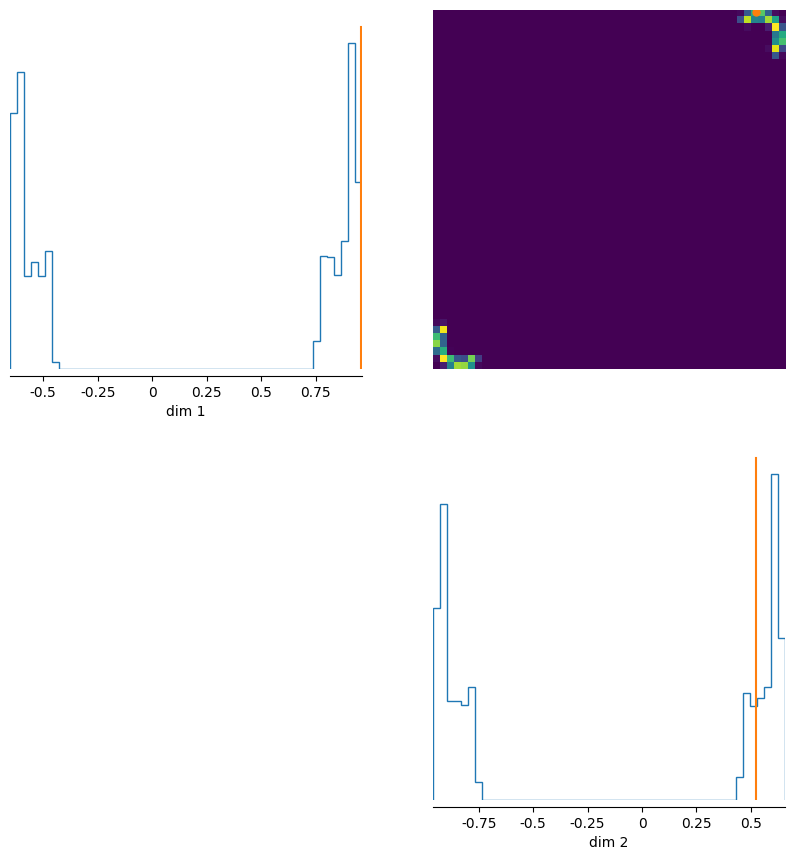

In [8]:
import matplotlib.pyplot as plt 
import seaborn as sns
from sbi.analysis import pairplot
import numpy as np

_ = pairplot(np.array(samples), points=np.array(theta[0]))

In [3]:
observation_stream = task.get_observation_generator()(jax.random.PRNGKey(3))
for i in range(30):
    # Two moons
    condition_mask, x_o, theta_o = next(observation_stream)
    # Two moons
    # samples = reference_sampler.sample(2000,x_o = x_o, condition_mask=condition_mask, rng=jax.random.PRNGKey(i))
    # _ = pairplot(np.array(samples), points=np.array(theta_o), upper="scatter")
    # plt.show()
    print(condition_mask)

[False False False False False False False False False False False False
 False]
[False False False False False  True  True  True  True  True  True  True
  True]
[ True  True  True  True  True False False False False False False False
 False]
[ True  True  True  True False  True  True  True  True  True  True  True
  True]
[ True  True  True False  True  True  True  True  True False False  True
  True]
[ True  True  True  True  True False False False False False False False
 False]
[False False  True  True False False False  True  True  True  True  True
  True]
[ True False  True  True False  True  True  True  True  True  True  True
  True]
[False False  True  True  True  True  True False False False False  True
  True]
[False False  True False False False False False False  True  True  True
  True]
[False False False False False False False False False False False False
 False]
[ True  True  True  True  True False False False False False False False
 False]
[False False  True False  Tr